In [1]:
import sys
import os
import time
import json
import re
import math
from datetime import datetime

import pandas as pd
import numpy as np
from tqdm import tqdm
import krippendorff
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import cohen_kappa_score



In [2]:
# File Paths 
MANUAL_ANNOTATION_FILE = "csv/manual_annotations.csv"
MANUAL_REANNOTATION_FILE = "csv/reannotated_50_rows.csv"

LLM_ANNOTATION_FILES = {
    "openai":     "csv/llm_annotations/llm_annotations_openai.csv",
    "anthropic":  "csv/llm_annotations/llm_annotations_anthropic.csv",
    "llama3b":   "csv/llm_annotations/llm_annotations_together_small.csv",
     # "4o-mini":     "csv/llm_annotations/llm_annotations_openai_mini.csv",
    # "deepseek":   "csv/llm_annotations/llm_annotations_deepseek.csv",
    # "llama70b":   "csv/llm_annotations/llm_annotations_together.csv",
    # "mistral7b":   "csv/llm_annotations/llm_annotations_together_minstral.csv",
   
}

MODELS = {
    1: {
        "llm_name_version": "gpt-4o-2024-08-06",
        "provider":         "openai",
        "display_name":     "GPT-4o",
        "rationale":        "Benchmark; used in Jia et al. 2024, Törnberg 2023/2025, Gilardi 2023"
    },
    2: {
        "llm_name_version": "claude-haiku-4-5-20251001",
        "provider":         "anthropic",
        "display_name":     "claude-haiku-4-5",
        "rationale":        "Efficient model for annotation tasks"
    },
    7: {
        "llm_name_version": "meta-llama/Llama-3.2-3B-Instruct-Turbo",
        "provider":         "llama3b",
        "display_name":     "Llama-3.2-3B",
        "rationale":        "Small open-weight baseline; genuine size contrast to Llama-3.3-70B"
    },
    # 3: {
    #     "llm_name_version": "deepseek-chat",
    #     "provider":         "deepseek",
    #     "display_name":     "DeepSeek-V3",
    #     "rationale":        "Cost-efficient frontier model with strong instruction-following"
    # },
    #  4: {
    #     "llm_name_version": "gpt-4o-mini",
    #     "provider":         "4o-mini",
    #     "display_name":     "GPT-4o-mini",
    #     "rationale":        "Comparison; OpenAI's smaller model, much weaker than GPT-4o"
    # },
    # 5: {
    #     "llm_name_version": "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    #     "provider":         "llama70b",
    #     "display_name":     "Llama-3.3-70B",
    #     "rationale":        "Open-source frontier model via Together AI"
    # },
    #  6: {
    #     "llm_name_version": "mistralai/Mistral-7B-Instruct-v0.3",
    #     "provider":         "mistral7b",
    #     "display_name":     "Mistral-7B",
    #     "rationale":        "Small open-weight baseline; standard benchmark in NLP annotation studies"
    # },
}

SCORE_COLS = ["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8"]


## 7. Reliability Analysis

This section computes the core statistics for Chapter 4 of the dissertation:

1. **Human–LLM agreement** (Krippendorff's α + Spearman ρ) - RQ1
2. **Inter-LLM consistency** (pairwise Krippendorff's α) — RQ2
3. **Score distribution comparison** — descriptive overview

**Important:** You need your human annotation file. Its format must match `OUTPUT_COLUMNS` or be convertible to it. If you annotated in a different tool (e.g. Google Sheets), load and align it below.

In [13]:
# 1. Load & Validate Manual Annotations
original_df = pd.read_csv(MANUAL_ANNOTATION_FILE)
reannotated_df = pd.read_csv(MANUAL_REANNOTATION_FILE)

required_manual_cols = ["row_id", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "total_score"]
missing = [c for c in required_manual_cols if c not in original_df.columns]
if missing:
    raise ValueError(f"Missing required columns in manual annotations: {missing}")

print(f"Manual annotation file loaded: {MANUAL_ANNOTATION_FILE}")
print(f"Loaded {len(original_df)} tweets\n")
print(original_df.dtypes)

missing = [c for c in required_manual_cols if c not in reannotated_df.columns]
if missing:
    raise ValueError(f"Missing required columns in manual annotations: {missing}")

print(f"Manual annotation file loaded: {MANUAL_ANNOTATION_FILE}")
print(f"Loaded {len(reannotated_df)} tweets\n")
print(reannotated_df.dtypes)




Manual annotation file loaded: csv/manual_annotations.csv
Loaded 301 tweets

row_id                  int64
post_type                 str
text                      str
V1                    float64
V2                    float64
V3                    float64
V4                    float64
V5                    float64
V6                    float64
V7                    float64
V8                    float64
total_score           float64
reason                    str
date                      str
annotation_session      int64
Unnamed: 16               str
dtype: object
Manual annotation file loaded: csv/manual_annotations.csv
Loaded 50 tweets

Annotation_Id           int64
row_id                  int64
post_type                 str
text                      str
V1                      int64
V1_reason                 str
V2                      int64
V2_reason                 str
V3                    float64
V3_reason                 str
V4                      int64
V4_reason              

In [18]:
# Load
original_df      = pd.read_csv(MANUAL_ANNOTATION_FILE)
reannotated_df = pd.read_csv(MANUAL_REANNOTATION_FILE)

# Strip all column names
original_df.columns      = original_df.columns.str.strip()
reannotated_df.columns = reannotated_df.columns.str.strip()

# Match on text
original_df      = original_df.set_index("text")
reannotated_df = reannotated_df.set_index("text")

# Keep only the 50 reannotated tweets
common_ids = reannotated_df.index.intersection(original_df.index)
print(f"Matched tweets for intra-rater reliability: {len(common_ids)}")

original  = original_df.loc[common_ids][SCORE_COLS]
reannoted = reannotated_df.loc[common_ids][SCORE_COLS]

# Drop NaNs
mask      = original.notna().all(axis=1) & reannoted.notna().all(axis=1)
original  = original[mask]
reannoted = reannoted[mask]
print(f"Clean matched tweets after dropping NaN: {len(original)}")

# Intra-rater Reliability
print("\n" + "=" * 75)
print("Intra-rater Reliability: Original vs. Re-annotation")
print("Krippendorff's alpha + Spearman rho + Cohen's Kappa (linear)")
print("=" * 75)
print(f"  {'Variable':<10} {'alpha':>7} {'rho':>7} {'p':>8} {'kappa':>7}")
print("-" * 75)

intra_records = []

for col in SCORE_COLS:
    orig_v   = original[col].values
    reanno_v = reannoted[col].values

    try:
        alpha = krippendorff.alpha(
            reliability_data=np.array([orig_v, reanno_v], dtype=float),
            level_of_measurement='ordinal'
        )
    except ValueError:
        alpha = float('nan')  # can't compute if no variation

    rho, p = spearmanr(orig_v, reanno_v)
    kappa  = cohen_kappa_score(orig_v, reanno_v, weights='linear')

    flag = " ⚠️" if kappa < 0.4 else ""
    print(f"  {col:<10} {alpha:>7.3f} {rho:>7.3f} {p:>8.4f} {kappa:>7.3f}{flag}")
    intra_records.append({
        "Variable":           col,
        "Krippendorff_alpha": round(alpha, 4) if not np.isnan(alpha) else None,
        "Spearman_rho":       round(rho, 4),
        "p_value":            round(p, 4),
        "Cohen_kappa":        round(kappa, 4),
    })

# Total score
orig_total   = original[SCORE_COLS].sum(axis=1).values
reanno_total = reannoted[SCORE_COLS].sum(axis=1).values
alpha_total  = krippendorff.alpha(
    reliability_data=np.array([orig_total, reanno_total], dtype=float),
    level_of_measurement='ordinal'
)
rho_total, p_total = spearmanr(orig_total, reanno_total)
kappa_total        = cohen_kappa_score(
    orig_total.astype(int), reanno_total.astype(int), weights='linear'
)
print(f"  {'TOTAL SCORE':<10} {alpha_total:>7.3f} {rho_total:>7.3f} {p_total:>8.4f} {kappa_total:>7.3f}")

intra_df = pd.DataFrame(intra_records)
intra_df.to_csv("csv/table_intra_rater_reliability.csv", index=False)
print("\nSaved: csv/table_intra_rater_reliability.csv")

Matched tweets for intra-rater reliability: 50
Clean matched tweets after dropping NaN: 48

Intra-rater Reliability: Original vs. Re-annotation
Krippendorff's alpha + Spearman rho + Cohen's Kappa (linear)
  Variable     alpha     rho        p   kappa
---------------------------------------------------------------------------
  V1           0.697   0.699   0.0000   0.617
  V2          -0.044  -0.044   0.7666  -0.034 ⚠️
  V3          -0.011  -0.021   0.8859  -0.021 ⚠️
  V4             nan     nan      nan     nan
  V5           0.375   0.375   0.0087   0.278 ⚠️
  V6           0.246   0.244   0.0948   0.270 ⚠️
  V7          -0.036   0.024   0.8715   0.052 ⚠️
  V8           0.364   0.499   0.0003   0.417
  TOTAL SCORE   0.578   0.622   0.0000   0.359

Saved: csv/table_intra_rater_reliability.csv


/var/folders/q8/tplwq65x58bf8st5czfxkmlw0000gn/T/ipykernel_79490/4249493773.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(orig_v, reanno_v)
/Users/mariameshi/Documents/year_5/Thesis/Code/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/mariameshi/Documents/year_5/Thesis/Code/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


In [12]:
# 2. Load & Validate LLM Annotations 
required_llm_cols = [
    "tweet_id", "llm_id", "llm_name_version",
    "V1", "V1_reason", "V2", "V2_reason", "V3", "V3_reason",
    "V4", "V4_reason", "V5", "V5_reason", "V6", "V6_reason",
    "V7", "V7_reason", "V8", "V8_reason",
    "total_score", "date", "annotation_session"
]

for model_key, model_info in MODELS.items():
    provider = model_info["provider"]
    df = pd.read_csv(LLM_ANNOTATION_FILES[provider])
    missing = [c for c in required_llm_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {provider}: {missing}")
    print(f"Loaded {model_info['display_name']}: {len(df)} tweets")

Loaded GPT-4o: 301 tweets
Loaded claude-haiku-4-5: 301 tweets
Loaded Llama-3.2-3B: 301 tweets


In [19]:
# 3. Align Human + LLM Annotations by tweet_id
# Load human annotations
# human_df = original_df.rename(columns={"row_id": "tweet_id"})
human_df = reannotated_df.rename(columns={"row_id": "tweet_id"})
human_df = human_df[["tweet_id"] + SCORE_COLS].dropna(subset=SCORE_COLS)
human_scores = human_df.set_index("tweet_id")

# Load LLM annotations
model_scores = {}
for model_key, model_info in MODELS.items():
    provider = model_info["provider"]
    df = pd.read_csv(LLM_ANNOTATION_FILES[provider])
    df = df[["tweet_id"] + SCORE_COLS].dropna(subset=SCORE_COLS)
    df = df.set_index("tweet_id")
    model_scores[model_info["display_name"]] = df

# Find common tweet_ids across human + all models
common_ids = set(human_scores.index)
for name, scores in model_scores.items():
    common_ids = common_ids.intersection(set(scores.index))
common_ids = list(common_ids)
print(f"\nTweets with complete annotations (human + all models): {len(common_ids)}")

human_aligned = human_scores.loc[common_ids]
model_aligned = {name: sc.loc[common_ids] for name, sc in model_scores.items()}


Tweets with complete annotations (human + all models): 48


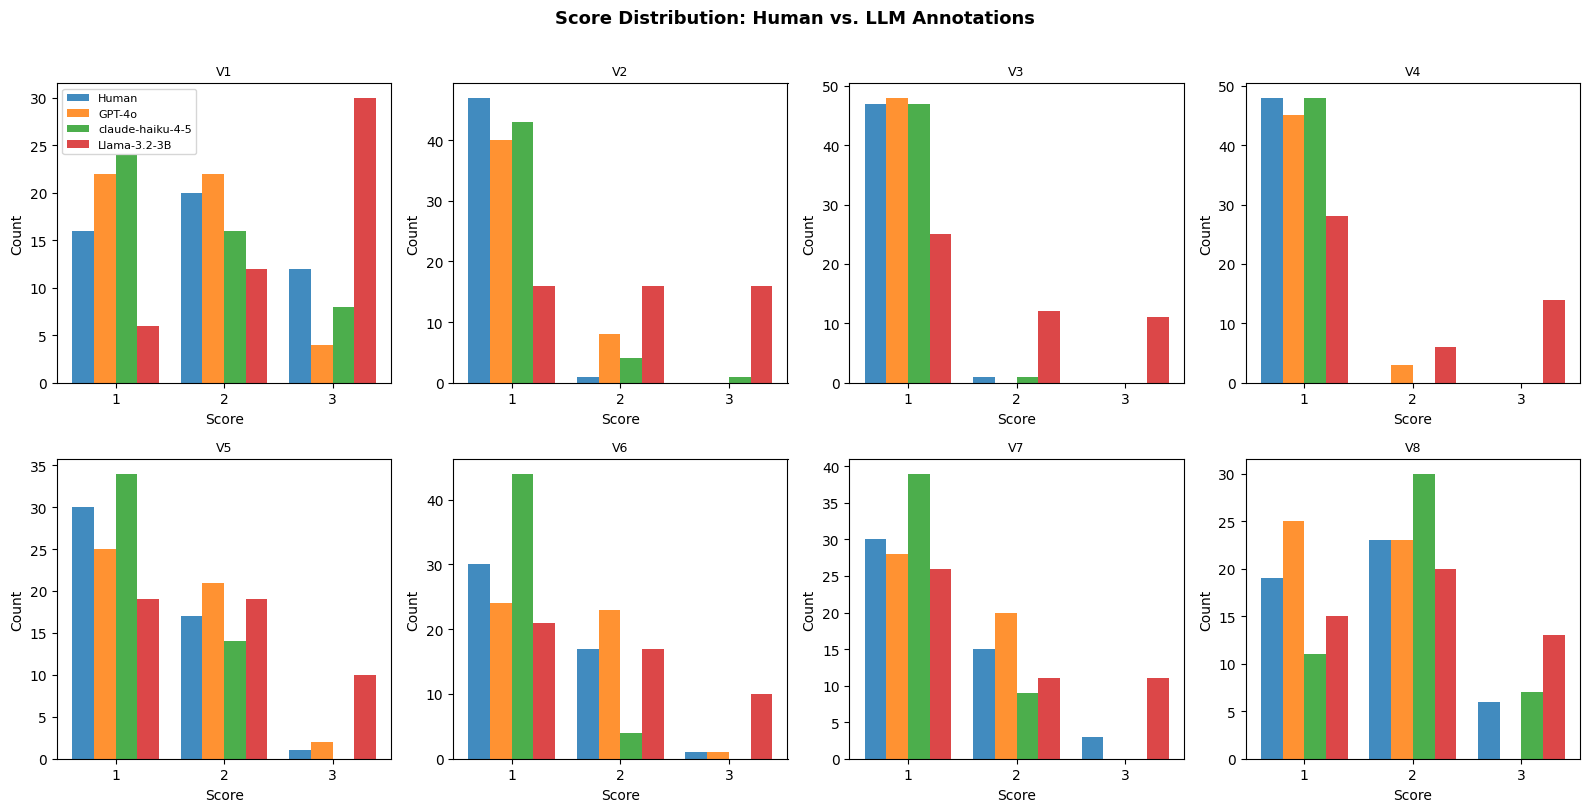

Saved: figure_score_distributions.png

Score Deviation: Human vs. LLM (per variable)
Mean absolute deviation from human score — flag if >= 1.0
  Variable  GPT-4o                  claude-haiku-4-5        Llama-3.2-3B          
----------------------------------------------------------------------
  V1        MAE=0.38 STD=0.58      MAE=0.29 STD=0.52      MAE=0.62 STD=0.73    
  V2        MAE=0.15 STD=0.35      MAE=0.10 STD=0.37      MAE=0.98 STD=0.80    
  V3        MAE=0.02 STD=0.14      MAE=0.00 STD=0.00      MAE=0.69 STD=0.79    
  V4        MAE=0.06 STD=0.24      MAE=0.00 STD=0.00      MAE=0.71 STD=0.89    
  V5        MAE=0.25 STD=0.48      MAE=0.27 STD=0.51      MAE=0.67 STD=0.84    
  V6        MAE=0.38 STD=0.63      MAE=0.35 STD=0.51      MAE=0.62 STD=0.83    
  V7        MAE=0.31 STD=0.56      MAE=0.29 STD=0.48      MAE=0.50 STD=0.75    
  V8        MAE=0.50 STD=0.72      MAE=0.48 STD=0.73      MAE=0.60 STD=0.87    

Saved: csv/table_score_deviations.csv

⚠️  Flagged = Mean Abso

In [20]:
# 4. Score Distribution Comparison + Std Deviation
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

all_annotators = {"Human": human_aligned, **model_aligned}
colors = [cm.tab10(i) for i in range(len(all_annotators))]

n = len(all_annotators)
width = 0.8 / n  # total bar group width = 0.8, divided equally

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    for j, (name, scores) in enumerate(all_annotators.items()):
        counts = scores[col].value_counts().sort_index()
        x = np.array([1, 2, 3])
        y = np.array([counts.get(v, 0) for v in x])
        offset = (j - n / 2 + 0.5) * width
        ax.bar(x + offset, y, width=width,
               label=name, color=colors[j], alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3])
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Score Distribution: Human vs. LLM Annotations",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("csv/figure_score_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure_score_distributions.png")

# Std Deviation Analysis
print("\n" + "=" * 70)
print("Score Deviation: Human vs. LLM (per variable)")
print("Mean absolute deviation from human score — flag if >= 1.0")
print("=" * 70)
print(f"  {'Variable':<8}", end="")
for name in model_aligned:
    print(f"  {name:<22}", end="")
print()
print("-" * 70)

deviation_records = []
DEVIATION_THRESHOLD = 1.0  # flag if mean abs deviation >= 1 point

for col in SCORE_COLS:
    human_v = human_aligned[col].values
    print(f"  {col:<8}", end="")
    for name, scores in model_aligned.items():
        model_v = scores[col].values
        mae  = np.mean(np.abs(model_v - human_v))       # mean absolute deviation
        std  = np.std(model_v - human_v)                 # std of deviation
        flag = " ⚠️" if mae >= DEVIATION_THRESHOLD else ""
        print(f"  MAE={mae:.2f} STD={std:.2f}{flag:<4}", end="")
        deviation_records.append({
            "Variable": col,
            "Model": name,
            "Mean_Abs_Deviation": round(mae, 4),
            "Std_Deviation": round(std, 4),
            "Flagged": mae >= DEVIATION_THRESHOLD
        })
    print()

deviation_df = pd.DataFrame(deviation_records)
deviation_df.to_csv("csv/table_score_deviations.csv", index=False)
print("\nSaved: csv/table_score_deviations.csv")
print(f"\n⚠️  Flagged = Mean Absolute Deviation >= {DEVIATION_THRESHOLD} point from human score")

In [15]:
# 5. Human–LLM Agreement: Krippendorff's alpha + Spearman rho (RQ1)
print("\n" + "=" * 75)
print("Human–LLM Agreement: Krippendorff's alpha + Spearman rho + Cohen's Kappa")
print("=" * 75)
print(f"{'Variable':<42} {'alpha':>7} {'rho':>7} {'p':>8} {'kappa':>7}")
print("-" * 75)

agreement_records = []

for model_name, model_sc in model_aligned.items():
    print(f"\n  ── {model_name} ──")
    for col in SCORE_COLS:
        human_v = human_aligned[col].values
        model_v = model_sc[col].values

        alpha = krippendorff.alpha(
            reliability_data=np.array([human_v, model_v], dtype=float),
            level_of_measurement='ordinal'
        )
        rho, p = spearmanr(human_v, model_v)
        kappa = cohen_kappa_score(human_v, model_v, weights='linear')  # linear = ordinal scale

        print(f"  {col:<40} {alpha:>7.3f} {rho:>7.3f} {p:>8.4f} {kappa:>7.3f}")
        agreement_records.append({
            "Model":              model_name,
            "Variable":           col,
            "Krippendorff_alpha": round(alpha, 4),
            "Spearman_rho":       round(rho, 4),
            "p_value":            round(p, 4),
            "Cohen_kappa":        round(kappa, 4),
        })

    # Total score
    human_total = human_aligned[SCORE_COLS].sum(axis=1).values
    model_total = model_sc[SCORE_COLS].sum(axis=1).values
    alpha_total = krippendorff.alpha(
        reliability_data=np.array([human_total, model_total], dtype=float),
        level_of_measurement='ordinal'
    )
    rho_total, p_total = spearmanr(human_total, model_total)
    kappa_total = cohen_kappa_score(
        human_total.astype(int), model_total.astype(int), weights='linear'
    )
    print(f"  {'TOTAL SCORE':<40} {alpha_total:>7.3f} {rho_total:>7.3f} {p_total:>8.4f} {kappa_total:>7.3f}")
    print(f"  {'(Jia et al. 2024 benchmark: rho = .75)':<40}")

agreement_df = pd.DataFrame(agreement_records)
agreement_df.to_csv("csv/table_human_llm_agreement.csv", index=False)
print("\nSaved: table_human_llm_agreement.csv")



Human–LLM Agreement: Krippendorff's alpha + Spearman rho + Cohen's Kappa
Variable                                     alpha     rho        p   kappa
---------------------------------------------------------------------------

  ── GPT-4o ──
  V1                                         0.576   0.606   0.0000   0.487
  V2                                        -0.018   0.069   0.2390   0.051
  V3                                         0.142   0.143   0.0143   0.139
  V4                                        -0.019  -0.020   0.7360  -0.015
  V5                                         0.267   0.338   0.0000   0.249
  V6                                         0.320   0.347   0.0000   0.275
  V7                                         0.110   0.215   0.0002   0.156
  V8                                         0.243   0.287   0.0000   0.200
  TOTAL SCORE                                0.607   0.644   0.0000   0.349
  (Jia et al. 2024 benchmark: rho = .75)  

  ── claude-haiku-4-5 ──
  V1 

In [16]:
# ── 6. Inter-LLM Consistency: Pairwise Krippendorff's alpha (RQ2) ────────────
print("\n" + "=" * 55)
print("Inter-LLM Consistency: Pairwise Krippendorff's alpha")
print("=" * 55)

# Re-align models without human (all 300 tweets)
model_aligned_all = {}
for model_key, model_info in MODELS.items():
    provider = model_info["provider"]
    df = pd.read_csv(LLM_ANNOTATION_FILES[provider])
    df = df[["tweet_id"] + SCORE_COLS].dropna(subset=SCORE_COLS)
    df = df.set_index("tweet_id")
    model_aligned_all[model_info["display_name"]] = df

common_ids_llm = list(set.intersection(*[set(df.index) for df in model_aligned_all.values()]))
for name in model_aligned_all:
    model_aligned_all[name] = model_aligned_all[name].loc[common_ids_llm]
print(f"Tweets annotated by all LLMs: {len(common_ids_llm)}")

model_names = list(model_aligned_all.keys())
inter_llm_records = []

for col in SCORE_COLS:
    print(f"\n  {col}")
    print(f"  {'Model A':<22} {'Model B':<22} {'alpha':>7}")
    print("  " + "-" * 55)

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            name_a, name_b = model_names[i], model_names[j]
            v_a = model_aligned_all[name_a][col].values
            v_b = model_aligned_all[name_b][col].values
            alpha = krippendorff.alpha(
                reliability_data=np.array([v_a, v_b], dtype=float),
                level_of_measurement='ordinal'
            )
            print(f"  {name_a:<22} {name_b:<22} {alpha:>7.3f}")
            inter_llm_records.append({
                "Variable": col, "Model_A": name_a,
                "Model_B": name_b, "Krippendorff_alpha": round(alpha, 4)
            })

    all_raters = np.array([model_aligned_all[n][col].values for n in model_names], dtype=float)
    multi_alpha = krippendorff.alpha(reliability_data=all_raters, level_of_measurement='ordinal')
    print(f"  {'Multi-rater (all LLMs)':<44} {multi_alpha:>7.3f}")

inter_llm_df = pd.DataFrame(inter_llm_records)
inter_llm_df.to_csv("csv/table_inter_llm_consistency.csv", index=False)
print("\nSaved: table_inter_llm_consistency.csv")


Inter-LLM Consistency: Pairwise Krippendorff's alpha
Tweets annotated by all LLMs: 301

  V1
  Model A                Model B                  alpha
  -------------------------------------------------------
  GPT-4o                 claude-haiku-4-5         0.802
  GPT-4o                 Llama-3.2-3B             0.081
  claude-haiku-4-5       Llama-3.2-3B             0.042
  Multi-rater (all LLMs)                         0.326

  V2
  Model A                Model B                  alpha
  -------------------------------------------------------
  GPT-4o                 claude-haiku-4-5         0.342
  GPT-4o                 Llama-3.2-3B             0.194
  claude-haiku-4-5       Llama-3.2-3B            -0.126
  Multi-rater (all LLMs)                         0.161

  V3
  Model A                Model B                  alpha
  -------------------------------------------------------
  GPT-4o                 claude-haiku-4-5         0.190
  GPT-4o                 Llama-3.2-3B            -

In [ ]:
# Agreement Heatmap
# Visualise pairwise rho across all annotators (human + LLMs) for total score.
# This is Figure 4.1 in the dissertation.

all_total_scores = {"Human": human_aligned[SCORE_COLS].sum(axis=1)}
for name, sc in model_aligned.items():
    all_total_scores[name] = sc[SCORE_COLS].sum(axis=1)

annotator_names = list(all_total_scores.keys())
n = len(annotator_names)
rho_matrix = np.zeros((n, n))

for i, name_i in enumerate(annotator_names):
    for j, name_j in enumerate(annotator_names):
        rho_matrix[i, j], _ = spearmanr(
            all_total_scores[name_i],
            all_total_scores[name_j]
        )

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(rho_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # Upper triangle masked

sns.heatmap(
    rho_matrix,
    annot=True, fmt=".2f",
    xticklabels=annotator_names,
    yticklabels=annotator_names,
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Spearman rho — Total Score\n(Human vs. LLMs)",
             fontweight='bold')
plt.tight_layout()
plt.savefig("figure_agreement_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure_agreement_heatmap.png")

## Qualitative Error Analysis

Identifies tweets with the largest disagreements between human and LLM annotations. These are the most analytically interesting cases for Section 4.4 of the dissertation.

Target: ~20 tweets for close reading, categorised by disagreement type.

In [ ]:
# Error Analysis
# Find tweets where human and LLM total scores diverge most

human_totals = human_aligned[SCORE_COLS].sum(axis=1).rename("human_total")

divergence_df = pd.DataFrame({"human_total": human_totals})

for name, sc in model_aligned.items():
    model_totals = sc[SCORE_COLS].sum(axis=1).rename(f"{name}_total")
    divergence_df[f"{name}_total"] = model_totals

# Compute mean absolute deviation from human score across all models
llm_total_cols = [f"{name}_total" for name in model_names]
divergence_df['mean_abs_deviation'] = divergence_df[llm_total_cols].subtract(
    divergence_df['human_total'], axis=0
).abs().mean(axis=1)

# Flag inter-LLM disagreement (max - min across LLM scores)
divergence_df['inter_llm_range'] = (
    divergence_df[llm_total_cols].max(axis=1) -
    divergence_df[llm_total_cols].min(axis=1)
)

# Top 20 most divergent tweets (human vs LLM)
top_divergent = divergence_df.nlargest(20, 'mean_abs_deviation')

# Add tweet text for qualitative reading
error_analysis = top_divergent.join(
    df.set_index(df.index)[['Tweet_Id', 'text', 'post_type']]
)

error_analysis.to_csv("table_error_analysis.csv", index=True)

print(f"Top 20 most divergent tweets (Human vs. LLMs)")
print(f"(Saved to table_error_analysis.csv for manual review)\n")
error_analysis[['human_total'] + llm_total_cols + ['mean_abs_deviation', 'text']].head(10)

In [ ]:
# ── Disagreement categorisation helper ────────────────────────────────────────
# After manually reading the top-20 tweets, use this cell to assign
# qualitative categories to disagreements. Categories follow Törnberg (2023)
# and the sample dissertation's emoji analysis approach:
#   - Sarcasm / irony
#   - Implicit partisan reference (requires context knowledge)
#   - Ambiguous framing
#   - Neutral / viral but misclassified

# Fill this in after manual review:
disagreement_categories = {
    # Row_ID: "category"
    # e.g. 42: "Sarcasm/irony",
    #      17: "Implicit reference",
}

print("Fill in 'disagreement_categories' after reading the top-20 tweets.")
print("Reference the tweets in table_error_analysis.csv.")

## Summary Statistics for Dissertation

Quick-reference outputs for copying into Chapter 4 tables.

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
# Dissertation Table 4.1: Human–LLM Agreement Summary

summary = agreement_df.groupby('Model').agg(
    Mean_alpha    = ('Krippendorff_alpha', 'mean'),
    Mean_rho      = ('Spearman_rho',       'mean'),
    Min_alpha     = ('Krippendorff_alpha', 'min'),
    Max_alpha     = ('Krippendorff_alpha', 'max'),
).round(3)

print("=" * 60)
print("Table 4.1: Human–LLM Agreement — Summary across V1–V8")
print("=" * 60)
print(summary.to_string())
print("\nBenchmark: Jia et al. (2024) Study 2 — rho = .75 (total score)")

summary.to_csv("table_4_1_summary.csv")
print("\n✅ All output tables and figures saved.")
print("\nFiles generated:")
for f in [
    OUTPUT_FILE,
    "table_human_llm_agreement.csv",
    "table_inter_llm_consistency.csv",
    "table_error_analysis.csv",
    "table_4_1_summary.csv",
    "figure_score_distributions.png",
    "figure_agreement_heatmap.png",
]:
    exists = "✅" if os.path.exists(f) else "⏳ (not yet generated)"
    print(f"  {exists}  {f}")